# https://velog.io/@hewas1230/StableDiffusion
# text to image 설명!!

# 프로세스

# 1. 기사 클릭해서 해당 기사 볼 수 있는 링크  

# 2. KoBART로 요약한 걸 아웃풋  

# 3. wordcloud, 연관 검색어 추천기능  

# 4. 추가 가능하다면 이미지를 인풋으로 한 후 위 프로세스 진행 혹은 이미지를 아웃풋으로 생성하기  

# 5. css mobirise활용해보기

In [1]:
!pip install konlpy==0.5.2
!pip install tweepy==3.10.0

In [2]:
import speech_recognition as sr
from transformers import PreTrainedTokenizerFast, BartForConditionalGeneration
import requests
from bs4 import BeautifulSoup
from matplotlib import font_manager
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from konlpy.tag import Okt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [ ]:
recog = sr.Recognizer()
with sr.Microphone() as source:
    print("음성 입력을 기다리고 있습니다.")
    audio_text = recog.listen(source)
    print("입력이 완료되었습니다.")
    try:
        query = recog.recognize_google(audio_text, language="ko-KR")
        print("음성 인식 결과: ", query)
    except:
        print("죄송합니다. 음성을 인식할 수 없습니다. 다시 시도해 주세요.")

In [3]:
query = input("내용을 입력해 주세요: ").strip()
if query:
    print("입력한 내용: ", query)
else:
    print("입력값이 비어있을 수 없습니다. 다시 시도하세요.")

내용을 입력해 주세요: 맛집
입력한 내용:  맛집


C:\Users\LEEYEJI\anaconda3\lib\site-packages\transformers\generation_utils.py:1648: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  next_indices = next_tokens // vocab_size


1. 제목: '나혼자산다' 정재광, 김요한과 동묘 닭한마리 맛집→한남동 크림 단팥...
   링크: http://enter.etoday.co.kr/news/view/275099
   본문: 비즈엔터 김세훈 기자 | 배우 정재광이 '나 혼자 산다'에서 집을 공개하고, 동묘에서 배우 김요한을 만나 동묘 닭한마리 맛집과 한남동 단팥빵 가게를... 정재광은 그가 가장 아끼고 사랑하는 동생인 배우 김요한과 동묘의 맛집 데이트를 함께한다. 맛집 리스트를 꿰고 있는 동생의 단골집에서 땀을 뻘뻘 흘리며...
   요약: 배우 정재광이 '나 혼자 산다'에서 가장 아끼고 사랑하는 동생인 배우 김요한과 동묘의 맛집 데이트를 함께한다.



C:\Users\LEEYEJI\anaconda3\lib\site-packages\transformers\generation_utils.py:1648: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  next_indices = next_tokens // vocab_size


2. 제목: 정재광 "김요한, 헬스장서 만나 맛집으로 친해져" 웃음
   링크: https://www.news1.kr/entertain/broadcast-tv/5743514
   본문: 특히 "헬스장에서 친해지고, '맛집 있는데 같이 갈래요?' 해서 음식으로 친해졌다"라는 고백이 웃음을 자아냈다. 이들이 동묘 쇼핑을 마치고, 곧바로 맛집으로 향했다. 김요한이 저장해 둔 닭요리 맛집이었다. 정재광이 "맛있다, 인정"이라며 맛을 음미했다. 그 누구보다 맛있게 먹는 김요한의 '먹방'이 웃음을...
   요약: 헬들이 헬스장에서 친해지고 '맛집 있는데 같이 갈래요?' 해서 음식으로 친해진다는 헬스장 생활과 함께 이들이 쇼핑을 마치고, 헬스장에 익숙해져 음식으로 친해진다는 김요한의 고백이 웃음을 자아냈다.

3. 제목: '10인 완전체 컴백' 싸이커스 "'퍼포먼스 맛집' 기대해주세요"
   링크: https://www.newsis.com/view/NISX20250403_0003126029
   본문: "강렬하고 속이 뻥 뚫리는 안무로 퍼포먼스 맛집으로 불리고 싶어요. 데뷔부터 지금까지 꾸준히 에너지 넘치는 퍼포먼스로 무대를 채워왔어요. 저희가 무대를 얼마나 사랑하는지 많은 분들이 알아봐 주셨으면 좋겠습니다. 이번 월드투어도 멋있게 마무리 해보겠습니다." (예찬)
   요약: "렬렬하고 속이 뻥 뚫리는 안무로 퍼포먼스 맛집으로 불리는 강렬하고 속이 뻥 뚫리는 안무로 퍼포먼스 맛집으로 이번 월드투어를 멋있게 마무리 하겠다고 멋있게 마무리 하겠다고 멋있게 마무리 하면서 이번 월드투어도 멋있게 마무리 해보겠습니다." (예찬) "이번 월드투어도 멋있게 마무리 해보겠습니다." (예찬) (예찬)" (예찬)"강렬하고 속이 뻥 뚫리는 안무로 퍼포먼스 맛집으로 불리고 싶습니다. 데뷔부터 지금까지 꾸준히 에너지 넘치는 퍼포먼스로 무대를 채워왔어요. 저희가 무대를 얼마나 사랑하는지 많은 분들이 알아봐 주셨으면 좋겠습니다. 이번 월드투어도 멋있게 마무리 해보겠습니다. 이번 월드투어도

4. 

20. 제목: ‘생방송 투데이’ 오늘방송맛집- 한우물의 법칙 삼계탕 맛집 ‘조○○...
   링크: https://www.etoday.co.kr/news/view/2458855
   본문: 이투데이=김해욱 기자 | SBS ‘생방송 투데이’ 오늘방송맛집- 한우물의 법칙 코너에서 ‘조○○○○○○’을 찾아간다. 3일 방송되는 ‘생방송 투데이’에서는 오늘방송맛집- 한우물의 법칙 코너를 통해 ‘조○○○○○○’의 특별한 맛을 집중 조명한다. 서울 관악구에 있는 ‘조○○○○○○’에서는...
   요약: SBS ‘생방송 투데이’ 오늘방송맛집- 한우물의 법칙 코너에서 ‘조○○○○○’을 찾아간다.

21. 제목: 부산 150곳 맛집 소개 책자 발간…4개 국어 지원
   링크: https://www.yna.co.kr/view/AKR20250331014900051?input=1195m
   본문: 부산시가 부산 대표 맛집 150곳의 정보를 담은 가이드 북 '2025 부산의 맛'을 발간했다고 31일 밝혔다. 이번 책은 맛집 정보를 한국어·영어·중국어·일본어 등 4개 국어로 소개하며 부산 미식 문화 정보도 제공한다. 안내서에는 맛집의 미식 이야기, 미식 흐름을 대표하는 셰프들의 인터뷰, '먹자골목', 향토...
   요약: 부산시가 부산 대표 맛집 150곳의 정보를 담은 가이드 북 '2025 부산의 맛'을 발간하여 4개 국어로 맛집 정보를 소개하며 부산 미식 문화 정보도 제공한다.

22. 제목: 동구전자 무인카페머신 '티타임A1'으로 '티타임 커피맛집' 현판 무상지...
   링크: http://www.e2news.com/news/articleView.html?idxno=318612
   본문: 동구전자가 '티타임A1' 무인카페 머신이 설치된 매장을 대상으로 '티타임 커피맛집' 현판을 무상 지원한다. 무인카페 머신 분야에서 독보적인 입지를... 동구전자는 최근 '티타임A1 샵인샵' TV 광고를 통해 티타임A1이 입점한 매장을 '커피맛집'으로 알리고 브랜드 이미지를 강화하는 데 주력하

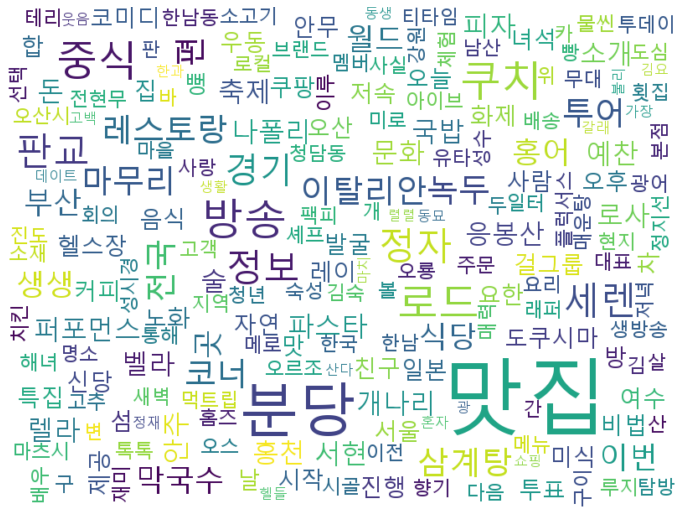

추천 연관 검색어:
1. 맛집
2. 분당
3. 방송
4. 쿠치
5. 중식
6. 로드
7. 정보
8. 정자
9. 판교
10. 세렌


In [4]:
# 모델과 토크나이저 로드

# 모델 둘 중에 하나 선택함.
tokenizer = PreTrainedTokenizerFast.from_pretrained("ainize/kobart-news")  # KoBART 모델의 토크나이저 로드
model = BartForConditionalGeneration.from_pretrained("ainize/kobart-news")  # KoBART 모델 로드

# tokenizer = PreTrainedTokenizerFast.from_pretrained("digit82/kobart-summarization")  # KoBART 모델의 토크나이저 로드
# model = BartForConditionalGeneration.from_pretrained("digit82/kobart-summarization")  # KoBART 모델 로드

# 텍스트 요약 함수 정의
def summarize_text(text, max_length=150):                                                                                          

    # 입력 텍스트를 모델에 맞게 인코딩
    inputs = tokenizer.encode(text, return_tensors="pt", max_length=1024, truncation=True)
    
    # 텍스트 요약 생성
    summary_ids = model.generate(
        input_ids=inputs,  # 인코딩된 텍스트
        bos_token_id=model.config.bos_token_id,  # 문장의 시작을 나타내는 토큰 ID
        eos_token_id=model.config.eos_token_id,  # 문장의 끝을 나타내는 토큰 ID
        length_penalty=2.0,  # 길이 패널티 설정
        max_length=max_length,  # 최대 길이 설정
        min_length=30,  # 최소 길이 설정
        num_beams=4,  # 빔 서치 사용 (4개의 후보 문장을 고려)
        early_stopping=True  # 조기 종료 설정
    )
    
    # 생성된 요약을 디코딩하여 반환
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

# 뉴스 기사 검색 함수 정의
def fetch_news(query, num_articles):
    
    news_articles = []  # 뉴스 기사를 저장할 리스트
    start = 1  # 페이지 시작 번호
    
    # 원하는 개수의 뉴스 기사를 가져올 때까지 반복
    while len(news_articles) < num_articles:
        # 네이버 뉴스 검색 URL 생성
        url = f"https://search.naver.com/search.naver?where=news&query={query}&sm=tab_etc&sort=0&photo=0&field=0&reporter_article=false&pd=0&docid=&nso=so:r,p:all,a:all&mynews=0&cluster_page=1&start={start}"
        response = requests.get(url)  # URL 요청
        response.raise_for_status()  # 요청 실패 시 예외 발생
        soup = BeautifulSoup(response.content, "html.parser")  # 응답 내용 파싱

        articles_on_page = []  # 현재 페이지의 기사 목록

        # 페이지에서 뉴스 기사 추출
        for news in soup.find_all("div", class_="news_area"):
            title = news.find("a", class_="news_tit").text.strip()  # 기사 제목
            link = news.find("a", class_="news_tit")["href"]  # 기사 링크
            text = news.find("div", class_="news_dsc").text.strip() if news.find("div", class_="news_dsc") else "본문 없음"  # 기사 본문 (없으면 "본문 없음"으로 설정)
            articles_on_page.append((title, link, text))  # 기사 정보를 리스트에 추가

        news_articles.extend(articles_on_page)  # 현재 페이지의 기사 목록을 전체 기사 목록에 추가
        
        # 원하는 개수의 기사를 가져왔으면 종료
        if len(news_articles) >= num_articles:
            break

        start += 10  # 다음 페이지로 이동

    return news_articles[:num_articles]  # 가져온 기사 목록 반환

# 연관 검색어 추천 함수 정의 (워드클라우드 기반)
def generate_related_searches_from_wordcloud(texts, top_n=10):
    # 텍스트를 문자열로 결합
    combined_text = " ".join(texts)
    
    # 한국어 형태소 분석기를 이용하여 명사 추출
    okt = Okt()
    nouns = okt.nouns(combined_text)  # 텍스트에서 명사 추출

    # 불용어 처리
    nouns = [n for n in nouns if n not in stopwords]  # 불용어를 제외한 명사 리스트

    # 단어 빈도수 계산
    count = Counter(nouns)  # 명사의 빈도수를 계산하여 카운터 객체 생성

    # 상위 n개의 연관 검색어를 반환
    return [word for word, freq in count.most_common(top_n)]

# 검색 쿼리 설정
news_articles = fetch_news(query, num_articles=30)  # 뉴스 기사 30개 검색

# 요약을 위한 텍스트 준비
all_summaries = []  # 요약 결과를 저장할 리스트

# 각 뉴스 기사에 대해 요약 생성
for i, (title, link, text) in enumerate(news_articles, start=1):
    summary = summarize_text(text)  # 기사 본문 요약
    all_summaries.append(summary)  # 요약을 리스트에 추가
    # 기사 정보 출력
    print(f"{i}. 제목: {title}")
    print(f"   링크: {link}")
    print(f"   본문: {text}")
    print(f"   요약: {summary}\n")

# 모든 요약을 하나의 문자열로 결합
all_summaries_text = " ".join(all_summaries)

# 한국어 형태소 분석기를 이용하여 명사 추출
okt = Okt()
nouns = okt.nouns(all_summaries_text)  # 텍스트에서 명사 추출

# 불용어 처리
# TF-IDF 점수가 낮은 단어 추출해보았으나 성능이 좋지 않음.
stopwords = [
    '의', '가', '이', '는', '다', '을', '를', '에', '에서', '에게', '과', '와',
    '도', '로', '저', '이것', '그것', '저것', '이런', '저런', '어떤',
    '무엇', '어디', '있다', '없다', '하다', '되다', '아니다', '보이다', '오다',
    '가다', '나가다', '들어가다', '된다', '한다', '해야', '해', '하고', '하면서',
    '그러나', '그런', '그래서', '즉', '바로', '등', '이외', '수', '경우', '관련',
    '내용', '일', '각', '일부', '그중', '그 외', '측', '대', '기간', '상태',
    '상황', '요인', '기준', '각종', '변동', '방법', '경향', '그들', '우리', '너',
    '저기', '이곳', '저곳', '그곳', '여기', '저기', '데', '및', '같은', '모든',
    '것', '들', '나', '우리는', '있는', '있는지', '한다면', '되는지', '되고',
    '되었던', '되고자', '해야', '하면서', '할지', '하고', '해'
]
nouns = [n for n in nouns if n not in stopwords]  # 불용어를 제외한 명사 리스트

# 단어 빈도수 계산
count = Counter(nouns)  # 명사의 빈도수를 계산하여 카운터 객체 생성

# 워드클라우드 생성
font_path = "C:/Windows/Fonts/malgun.ttf"  # 워드클라우드에 사용할 폰트 경로
wordcloud = WordCloud(font_path=font_path, background_color='white', max_font_size=100, width=800, height=600).generate_from_frequencies(count)  # 단어 빈도수로부터 워드클라우드 생성

# 워드클라우드 시각화
plt.figure(figsize=(12, 10))  # 그림 크기 설정
plt.imshow(wordcloud, interpolation='bilinear')  # 워드클라우드 이미지를 그림에 표시
plt.axis("off")  # 축 숨기기
plt.show()  # 그림 출력

# 연관 검색어 추천
related_searches = generate_related_searches_from_wordcloud(all_summaries, top_n=10)
print("추천 연관 검색어:")

# 연관 검색어 출력
for i, search in enumerate(related_searches, start=1):
    print(f"{i}. {search}")

# 검색어를 입력하면 Stable Diffusion을 통해 이미지를 생성
## 런타임 -> 런타임 유형 변경 -> None이 아닌 GPU로 설정해야 합니다.

In [ ]:
!pip install translate==3.6.1
!nvidia-smi
!pip install diffusers
!pip install transformers scipy ftfy
!pip install "ipywidgets>=7,<8"
import torch
from diffusers import StableDiffusionPipeline
from torch import autocast
from translate import Translator
from google.colab import output
output.enable_custom_widget_manager()
from huggingface_hub import notebook_login
from IPython.display import clear_output
clear_output(wait=True)

notebook_login()

In [ ]:
# 사용자가 특정 주제에 대해 관심을 가지면, 해당 주제와 관련된 이미지를 생성하여 시각적으로 표현

translator = Translator(from_lang="ko", to_lang="en") # 한국어를 영어로 바꿔주는 translator 객채생성
translation = translator.translate(query) # 객체의 translate 메소드(함수)로 한국어를 영어로 번역(안녕하세요-> hello)

generator = torch.Generator("cuda").manual_seed(1026)

pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", revision="fp16", torch_dtype=torch.float16, use_auth_token=True)  

pipe = pipe.to("cuda")

prompt = translation
with autocast("cuda"):
  image = pipe(prompt, num_inference_steps=60, generator=generator).images[0]
image